### **Triển khai một mô hình phân loại hình ảnh dựa trên CNN sử dụng thư viện PyTorch**

**Bước 1.Import các thư viện cần thiết**

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision

**Bước 2. Định nghĩa Data Transformations và loat dataset MNIST**
###### -torchvision.transforms.Compose dùng để ghép nhiều phép biến đổi ảnh lại với sau
###### -ToTensor() chuyển ảnh sang Tensor và chuẩn hóa giá trị pixel từ (0-215) -> (0-1)
###### -Nomalize() đưa giá trị pixel về lại trong khoảng [-1, 1] giúp training ổn định hơn, gradient hội tụ nhanh hơn, model học tốt h
###### -Lựa chọn dataset MINIST cho bài toán mẫu

In [2]:
normalize_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=(0.5,), std=(0.5,))
])

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    transform=normalize_transform,
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    transform=normalize_transform,
    download=True,
)

**Bước 3: Tạo các Data Loaders**

###### -batch_size = 64

###### -Tạo data loaders cho cả dữ liệu train và test

In [3]:
batch_size = 64
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, drop_last=True)


**Bước 4: Hình dung một số mẫu ảnh**

In [ ]:
dataiter = iter(train_loader)
images, labels = next(dataiter)
plt.imshow(np.transpose(torchvision.utils.make_grid(
    images[:25], normalize=True, padding=1, nrow=5).numpy(), (1, 2, 0)))
plt.axis('off')
plt.show()

**Bước 5: Phân tích sự phân bổ của các class**

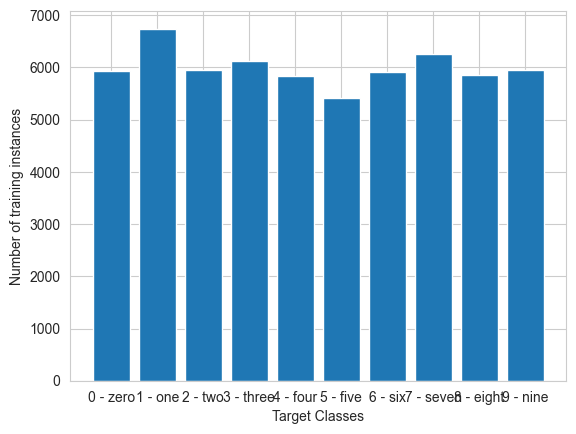

In [5]:
classes = []
for batch_idx, data in enumerate(train_loader):
    x, y = data
    classes.extend(y.tolist())

unique, counts = np.unique(classes, return_counts=True)
names = list(test_dataset.class_to_idx.keys())
plt.bar(names, counts)
plt.xlabel("Target Classes")
plt.ylabel("Number of training instances")
plt.show()

**Bước 6: Xây dựng cấu trúc CNN sử dụng PyTorch**

###### -Mô hình gồm 2 lớp tích chập, lớp kích hoạt, lớp pooling
###### -Lớp Flatten dùng để giảm chiều không gian của feature map, thêm hai lớp fully connected
##### -Lớp đầu ra là điểm số dự đoán cho 10 lớp

In [6]:
class CNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.model = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),
            torch.nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),
            torch.nn.Flatten(),
            torch.nn.Linear(32 * 7 * 7, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, 10)
        )
    def forward(self, x):
        return self.model(x)

Bước 7: Cấu hình quy trình huấn luyện

###### -Sử dụng thiêt bị tính toán là CPU hoặc GPU (nếu có)

###### -Khởi tạo mô hình và chuyển đến thiết bị đã chọn

###### -Số lượng epoch huấn luyện = 3 giúp train nhanh

###### -Sử dụng CrossEntropyLoss, tối ưu Adam, tốc độ học 0.001

In [7]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = CNN().to(device)

num_epochs = 3
learning_rate = 0.001
weight_decay = 0.01
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(), lr=learning_rate, weight_decay=weight_decay
)

**Bước 8: Huấn luyện model**

##### *Quy trình huấn luyện với mỗi epoch:

###### - Lấy dữ liệu ảnh và nhãn theo từng batch và chuyển sang cùng thiết bị
###### - Cho dữ liệu đi qua mô hình để dự đoán outputs
###### - Tính toán loss giữa dự đoán và nhãn thật
###### - Xóa grandient cũ (optimizer.zero_grad())
###### - Lan truyền ngược để tính gradient mới (loss.backward())
###### - Cập nhật trọng số mô hình (optimizer.step())


In [8]:
train_loss_list = []
for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}:', end=' ')
    train_loss = 0
    model.train()
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss_list.append(train_loss / len(train_loader))
    print(f"Training loss = {train_loss_list[-1]}")

Epoch 1/3: Training loss = 0.23257578612823507
Epoch 2/3: Training loss = 0.12268236318805706
Epoch 3/3: Training loss = 0.11320811202987902


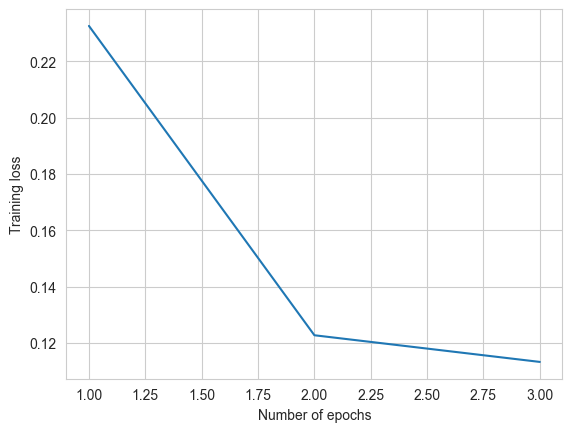

In [10]:
plt.plot(range(1, num_epochs + 1), train_loss_list)
plt.xlabel("Number of epochs")
plt.ylabel("Training loss")
plt.show()

**Bước 9: Đánh giá độ chính xác của mô hình**

In [11]:
test_acc = 0
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        y_true = labels.to(device)
        outputs = model(images)
        _, y_pred = torch.max(outputs.data, 1)
        test_acc += (y_pred == y_true).sum().item()
print(f"Test set accuracy = {100 * test_acc / len(test_dataset)} %")

Test set accuracy = 96.56 %


**Bước 10: Thự nghiệm kết quả dự đoán của mô hình trên tập test**

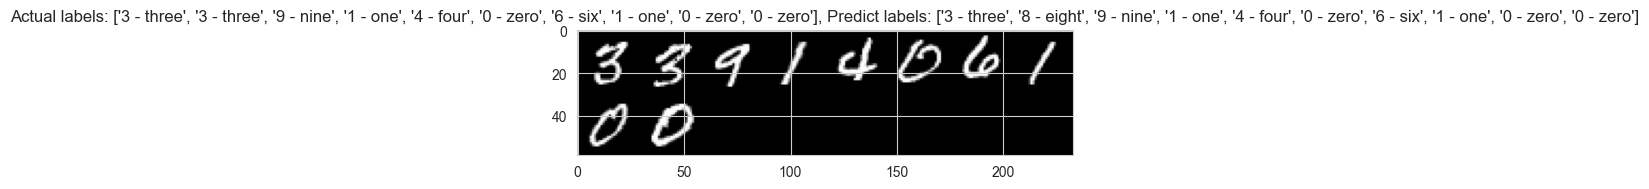

torch.Size([64, 1, 28, 28])

In [14]:
num_images = 10
y_true_name = [names[y_true[23 + idx]] for idx in range(num_images)]
y_pred_name = [names[y_pred[23 + idx]] for idx in range(num_images)]
title = f"Actual labels: {y_true_name}, Predict labels: {y_pred_name}"

plt.imshow(np.transpose(torchvision.utils.make_grid(
    images[23:23 + num_images].cpu(), normalize=True, padding=1).numpy(), (1, 2, 0)))
plt.title(title)
plt.show()